# Homework 1: Fluid properties and fluid statics with Python

#### Notebook Submission Deadline: Tuesday 22 September 2026 (by 9pm)

#### Homework Written Defence: Wednesday 23 September 2026 (at 5pm)

#### Credits: 25 points

## Name: Alejandro Silva

- When you finish, please submit your notebook via the link provided.

- This homework is individual. Please include your name in the notebook.

- Within a **single python notebook**, solve the following problems:

# Problem 1. Dynamic viscosity of liquid mixtures

The dynamic viscosity of a liquid, $\mu$, falls steeply as the temperature rises. Over a moderate temperature range this behaviour is well described by the **Andrade equation**:

$$\mu = D\,e^{B/T}$$

where:
- $\mu$ is the dynamic viscosity,
- $T$ is the absolute temperature,
- $B$ and $D$ are constants that depend on the liquid.

Taking logarithms, we obtain:

$$\ln \mu = \ln D + B\left(\frac{1}{T}\right)$$

### The data set:

You will work with real experimental measurements contained in the file **PGGLWdata.csv**.

To obtain the file, go to the article page , open its **Supporting Information**, download the archive **ie0c00379_si_002.zip**, and unzip it. The file you need is here:

https://acs.figshare.com/articles/dataset/Viscosity_Model_for_Liquid_Mixtures_of_Propylene_Glycol_Glycerol_and_Water/13483284?file=25877910

```
Data/AveragedData/PGGLWdata.csv
```

##### Reference: Spann, A. P. et al. (2021), "Viscosity Model for Liquid Mixtures of Propylene Glycol, Glycerol, and Water", Industrial & Engineering Chemistry Research, 60, 670-677. https://doi.org/10.1021/acs.iecr.0c00379


The file holds $657$ viscosity measurements of $9$ different liquid mixtures of propylene glycol (PG), glycerol (GL) and water (W), each measured at $73$ temperatures between $\sim 293\,\rm K$ and $\sim 353\,\rm K$ ($20-80^{\circ}\rm C$). Its columns are:

| Column | Meaning |
|--------|---------|
| `Temp(K)` | temperature, $T$, in $\rm K$ |
| `MF_PG` | mass fraction of propylene glycol |
| `MF_GL` | mass fraction of glycerol |
| `MF_W` | mass fraction of water |
| `MF_MEN` | mass fraction of menthol (zero in every row of this file) |
| `Visc(Pa*s)` | measured dynamic viscosity, $\mu$, in $\rm Pa\,s$ |
| `Visc Std Dev(Pa*s)` | standard deviation of the repeated measurements, in $\rm Pa\,s$ |
| `Visc Range (Pa*s)` | full range of the repeated measurements, in $\rm Pa\,s$ |


### Coding tasks:

## Data I/O and visualisation:

#### **(a)** Inspect the structure of the file. Then, create a python function that uses **pandas** to read in the **PGGLWdata.csv** file, places the data into a pandas dataframe, and returns the temperatures, the three mass fractions, the viscosities and the viscosity standard deviations as arrays. Display the first rows of the dataframe and report how many distinct mixtures the file contains. (**Hint:** a mixture is identified by its triplet of mass fractions).

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, optimize
from scipy.optimize import brentq
import sympy as sp

import scienceplots

# Set plots style
plt.style.use(['science', 'notebook', 'no-latex'])

In [2]:
# Data
file_path = "./PGGLWdata.csv"

# Reading the file and converting the columns to arrays
def load_mixtures(filename):
    """
    Reads the liquid mixtures dataset and returns the temperatures, the three mass fractions,\
    the viscosities and the viscosity standard deviations as arrays.

    Parameters
    ----------
    filename : str
        Path to the CSV file.

    Returns
    -------
    df : pandas.DataFrame
        Complete dataset.

    T : numpy.ndarray
        Temperature [K].

    MF_PG : numpy.ndarray
        Mass fraction of propylene glycol.

    MF_GL : numpy.ndarray
        Mass fraction of glycerol.

    MF_W : numpy.ndarray
        Mass fraction of water.

    mu : numpy.ndarray
        Dynamic viscosity [Pa s].

    mu_std : numpy.ndarray
        Standard deviation of viscosity [Pa s].
    """
    # Read the file using pandas
    df = pd.read_csv(filename)

    # Convert to numpy arrays
    T = df["Temp(K)"].to_numpy()
    MF_PG = df["MF_PG"].to_numpy()
    MF_GL = df["MF_GL"].to_numpy()
    MF_W = df["MF_W"].to_numpy()

    mu = df["Visc(Pa*s)"].to_numpy()
    mu_std = df["Visc Std Dev(Pa*s)"].to_numpy()

    return df, T, MF_PG, MF_GL, MF_W, mu, mu_std

# Call the function
df, T, MF_PG, MF_GL, MF_W, mu, mu_std = load_mixtures(file_path)

# Display the first rows
df.head()

,Temp(K),MF_PG,MF_GL,MF_W,MF_MEN,Visc(Pa*s),Visc Std Dev(Pa*s),Visc Range (Pa*s)
0,293.0875,0.2375,0.7125,0.05,0,0.288001,0.001518,0.003483
1,293.9240,0.2375,0.7125,0.05,0,0.269155,0.001559,0.003793
2,294.7660,0.2375,0.7125,0.05,0,0.251358,0.001650,0.003656
3,295.5910,0.2375,0.7125,0.05,0,0.234903,0.001734,0.004062
4,296.4260,0.2375,0.7125,0.05,0,0.219796,0.001370,0.003195


We have measures of the same mixture at different temperatures.

In [3]:
# Identify the different liquid mixtures by the triple mass fractions
mixtures = (df[["MF_PG", "MF_GL", "MF_W"]].drop_duplicates().reset_index(drop=True))

print(f"\nNumber of distinct mixtures: {len(mixtures)}")
display(mixtures)


Number of distinct mixtures: 9


,MF_PG,MF_GL,MF_W
0,0.2375,0.7125,0.05
1,0.4750,0.4750,0.05
2,0.7125,0.2375,0.05
3,0.2250,0.6750,0.10
4,0.4500,0.4500,0.10
5,0.6750,0.2250,0.10
6,0.2000,0.6000,0.20
7,0.4000,0.4000,0.20
8,0.6000,0.2000,0.20


#### **(b)** Make a high-quality, labeled plot of the dynamic viscosity $\mu$ (in $\rm Pa\,s$) versus temperature $T$ (in $\rm K$) for all $9$ mixtures, with one colour per mixture, y-error bars equal to the standard deviations, and a logarithmic Y axis.

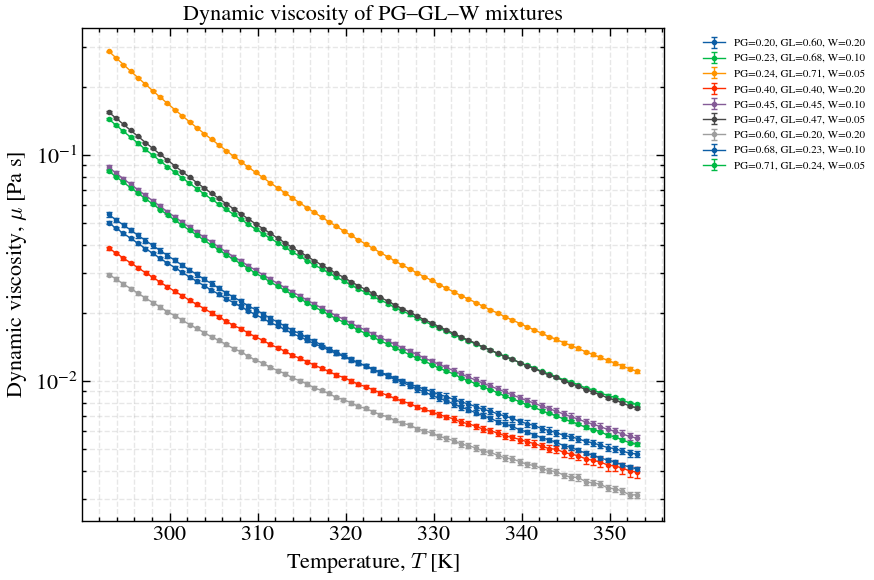

In [4]:
# Figure
plt.figure(figsize=(9, 6))

# Group the data by composition
for (mf_pg, mf_gl, mf_w), group in df.groupby(["MF_PG", "MF_GL", "MF_W"]):
    
    # Sort by temperature so that the curve is plotted in the correct order
    group = group.sort_values("Temp(K)")
    
    label = (
        f"PG={mf_pg:.2f}, "
        f"GL={mf_gl:.2f}, "
        f"W={mf_w:.2f}"
    )
    
    plt.errorbar(
        group["Temp(K)"],
        group["Visc(Pa*s)"],
        yerr=group["Visc Std Dev(Pa*s)"],
        marker="o",
        markersize=3,
        linewidth=1,
        capsize=2,
        label=label
    )
# y-axis logarithmic scale
plt.yscale("log")

# Labels
plt.xlabel("Temperature, $T$ [K]")
plt.ylabel("Dynamic viscosity, $\\mu$ [Pa s]")
plt.title("Dynamic viscosity of PG–GL–W mixtures")

plt.grid(True, which="both", alpha=0.3, linestyle="--")
plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **(c)** Now look at the composition dependence near $25^{\circ}\rm C$. For each mixture, select the measurement whose temperature is closest to $T = 298.15\,\rm K$, and make a second high-quality, labeled plot with the glycerol mass fraction on the X axis, the dynamic viscosity on the Y axis, and one curve per water mass fraction ($5\%$, $10\%$ and $20\%$).

In [5]:
T_target = 298.15

# Distance of every measurement from 298.15 K
df["delta_T"] = np.abs(df["Temp(K)"] - T_target)

# For each mixture, find the index of the closest temperature
closest_indices = (
    df.groupby(["MF_PG", "MF_GL", "MF_W"])["delta_T"]
    .idxmin()
)

# Extract those rows
df_25C = df.loc[closest_indices].copy()

df_25C = df_25C.sort_values(["MF_W", "MF_GL"])

display(df_25C[
    ["Temp(K)", "MF_PG", "MF_GL", "MF_W", "Visc(Pa*s)"]
])

,Temp(K),MF_PG,MF_GL,MF_W,Visc(Pa*s)
152,298.10000,0.7125,0.2375,0.05,0.060644
79,298.11100,0.4750,0.4750,0.05,0.106901
6,298.10200,0.2375,0.7125,0.05,0.192454
371,298.09275,0.6750,0.2250,0.10,0.039807
298,298.10400,0.4500,0.4500,0.10,0.062674
225,298.09000,0.2250,0.6750,0.10,0.099927
590,298.11100,0.6000,0.2000,0.20,0.022242
517,298.10700,0.4000,0.4000,0.20,0.028750
444,298.09200,0.2000,0.6000,0.20,0.036743


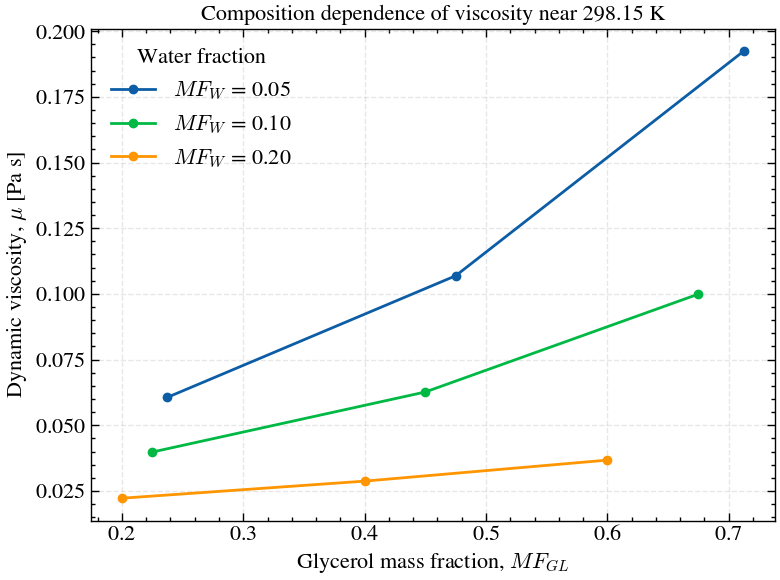

In [6]:
# Figure
plt.figure(figsize=(8, 6))

# Define water fractions
water_fractions = [0.05, 0.10, 0.20]

for mf_w in water_fractions:
    # For the given temperatures find the closest water fractions
    subset = df_25C[np.isclose(df_25C["MF_W"], mf_w)]
    subset = subset.sort_values("MF_GL")
    
    plt.plot(
        subset["MF_GL"],
        subset["Visc(Pa*s)"],
        marker="o",
        linewidth=2,
        label=f"$MF_W$ = {mf_w:.2f}"
    )
# Labels
plt.xlabel("Glycerol mass fraction, $MF_{GL}$")
plt.ylabel("Dynamic viscosity, $\\mu$ [Pa s]")
plt.title("Composition dependence of viscosity near 298.15 K")

plt.grid(True, alpha=0.3, linestyle="--")
plt.legend(title="Water fraction")

plt.tight_layout()
plt.show()

* At constant water content, increasing glycerol generally increases viscosity.
* Increasing the amount of water generally reduces the viscosity substantially.

## Regressions:

#### **(d)** Choose one mixture and build the vectors $x = 1/T$ and $y = \ln\mu$. Carry out a **linear regression** to obtain $B$ and $\ln D$. Report the regression equation first,

$$\ln\mu = \ln D + B\left(\frac{1}{T}\right),$$

and then the numerical values of $B$ and $D$ together with their units. Make a high-quality, labeled plot of the data points and the **best-fit line** on the $(1/T,\,\ln\mu)$ plane.

In [7]:
# Defining a function, it'll be used for all 9 mixtures
def fit_andrade(T, mu):
    """
    Fit the Andrade viscosity model:

        mu = D * exp(B / T)

    which becomes linear after taking logarithms:

        ln(mu) = ln(D) + B * (1/T)

    Parameters
    ----------
    T : array-like
        Temperature values [K].

    mu : array-like
        Dynamic viscosity values [Pa s].

    Returns
    -------
    B : float

    D : float

    lnD : float

    y_pred : numpy.ndarray
        Predicted values of ln(mu).

    residuals : numpy.ndarray
        Residuals:
        ln(mu_data) - ln(mu_fit).

    rms : float
        Root-mean-square residual.
    """

    # Convert inputs to NumPy arrays
    T = np.asarray(T)
    mu = np.asarray(mu)

    # Linearized Andrade variables
    x = 1 / T
    y = np.log(mu)

    # Linear regression:
    # y = B*x + ln(D)
    B, lnD = np.polyfit(x, y, 1)

    # Recover D
    D = np.exp(lnD)

    # Predicted ln(mu)
    y_pred = lnD + B * x

    # Residuals
    residuals = y - y_pred

    # RMS residual
    rms = np.sqrt(np.mean(residuals**2))

    return B, D, lnD, y_pred, residuals, rms

$B$ must have units of temperature to cancel out, and because on the RHS we have dynamic viscosity the units of $D$ must be Pa.s.

In [8]:
# Testing for one mixture
mixture_d = mixtures.iloc[5]

# Select all measurements belonging to this mixture
mask_d = (
    np.isclose(MF_PG, mixture_d.MF_PG) &
    np.isclose(MF_GL, mixture_d.MF_GL) &
    np.isclose(MF_W, mixture_d.MF_W)
)

# Regression
B, D, lnD, y_pred, residuals_d, rms = fit_andrade(T[mask_d], mu[mask_d])

# Report results
print("Andrade regression results:")
print("-" * 20)
print(f"Mixture: PG {mixture_d.MF_PG:.2%}, GL {mixture_d.MF_GL:.2%}, W {mixture_d.MF_W:.2%}")
print("-" * 20)

print(
    f"Regression equation: ln(mu) = {lnD:.6f} "
    f"+ ({B:.3f} K)(1/T)"
)

print(f"B = {B:.3f} K")
print(f"D = {D:.6e} Pa·s")
print(f"RMS residual = {rms:.6e}")

Andrade regression results:
--------------------
Mixture: PG 67.50%, GL 22.50%, W 10.00%
--------------------
Regression equation: ln(mu) = -18.129807 + (4425.647 K)(1/T)
B = 4425.647 K
D = 1.337595e-08 Pa·s
RMS residual = 5.055052e-02


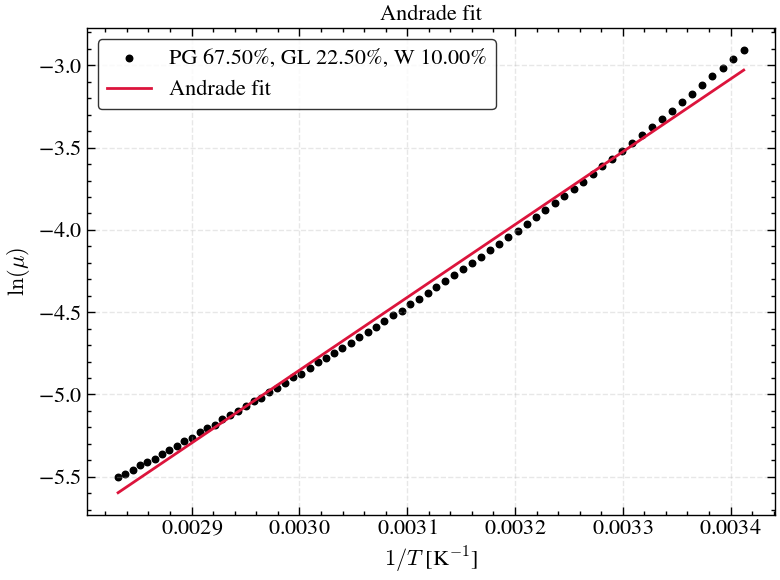

In [9]:
# Plotting
# Variables for the linearized Andrade equation
x = 1 / T[mask_d]
y = np.log(mu[mask_d])

# Create a smooth range for the fitted line
x_fit = np.linspace(x.min(), x.max(), 300)

# Andrade regression line
y_fit = lnD + B * x_fit

# Plot
plt.figure(figsize=(8, 6))

# Experimental data
plt.scatter(
    x,
    y,
    s=22,
    label=f"PG {mixture_d.MF_PG:.2%}, GL {mixture_d.MF_GL:.2%}, W {mixture_d.MF_W:.2%}",
    color="black"
)

# Best-fit line
plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label="Andrade fit",
    color="crimson"
)

plt.xlabel(r"$1/T$ [K$^{-1}$]")
plt.ylabel(r"$\ln(\mu)$")
plt.title("Andrade fit")

plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black')

plt.tight_layout()
plt.show()

#### **(e)** Repeat the regression of point (d) for all $9$ mixtures, and report the results in a table containing `MF_PG`, `MF_GL`, `MF_W`, $B$ and $D$.

In [10]:
# Store the regression results for all mixtures
andrade_results = []

for _, mixture in mixtures.iterrows():

    # Select all measurements belonging to this mixture
    mask = (
        np.isclose(MF_PG, mixture.MF_PG) &
        np.isclose(MF_GL, mixture.MF_GL) &
        np.isclose(MF_W, mixture.MF_W)
    )

    # Apply the Andrade regression
    B, D, lnD, y_pred, residuals, rms = fit_andrade(T[mask], mu[mask])

    # Store only the quantities requested in part (e)
    andrade_results.append({
        "MF_PG": mixture.MF_PG,
        "MF_GL": mixture.MF_GL,
        "MF_W": mixture.MF_W,
        "B [K]": B,
        "D [Pa·s]": D,
        "RMS residual": rms
    })

# Convert the results into a DataFrame
andrade_table = pd.DataFrame(andrade_results)

# Display the table
andrade_table

,MF_PG,MF_GL,MF_W,B [K],D [Pa·s],RMS residual
0,0.2375,0.7125,0.05,5577.257519,1.331829e-09,0.070067
1,0.4750,0.4750,0.05,5144.704818,3.179699e-09,0.062658
2,0.7125,0.2375,0.05,4757.128092,6.685350e-09,0.052866
3,0.2250,0.6750,0.10,4960.822250,5.479368e-09,0.067038
4,0.4500,0.4500,0.10,4716.945503,7.859976e-09,0.058698
5,0.6750,0.2250,0.10,4425.647206,1.337595e-08,0.050551
6,0.2000,0.6000,0.20,4002.139688,5.046464e-08,0.062169
7,0.4000,0.4000,0.20,3865.793533,6.239533e-08,0.062733
8,0.6000,0.2000,0.20,3813.366365,5.815697e-08,0.054231


#### **(f)** For the mixture of point (d), calculate the **residuals of the fit**, $\ln\mu_{\rm data} - \ln\mu_{\rm fit}$, make a labeled residual plot, and report the root-mean-square residual. Then, repeat the calculation of the root-mean-square residual for all $9$ mixtures and add it as an extra column to the table of point (e).

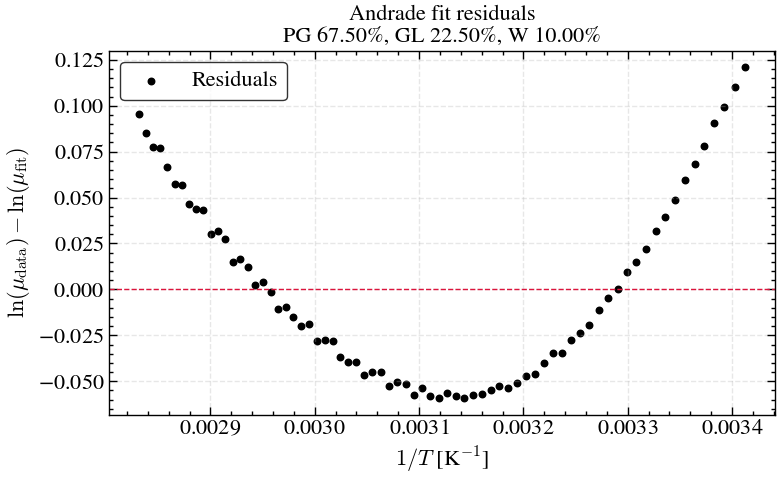

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    1/T[mask_d],
    residuals_d,
    s=22,
    label="Residuals",
    color="black"
)

# Zero-residual reference line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    color="crimson"
)

plt.xlabel(r"$1/T$ [K$^{-1}$]")
plt.ylabel(r"$\ln(\mu_{\mathrm{data}}) - \ln(\mu_{\mathrm{fit}})$")
plt.title(
    "Andrade fit residuals\n"
    f"PG {mixture_d.MF_PG:.2%}, "
    f"GL {mixture_d.MF_GL:.2%}, "
    f"W {mixture_d.MF_W:.2%}"
)

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(frameon=True, facecolor="white", edgecolor="black")

plt.tight_layout()
plt.show()

## Analysis questions:

#### **(g)** What happens to the dynamic viscosity as the temperature increases? And, at a fixed temperature, what happens when the glycerol mass fraction increases? What happens when the water mass fraction increases?

For all mixtures, dynamic viscosity ($\mu$) reduces as temperature increases because the particles have more molecular thermal motion, the resistance to flow is reduced. The viscosity also decreases as the water mass fraction ($MF_W$) increases, water contrarrest the effect of glicerol.
On the other hand, at a fixed temperature $\mu$ increases as MF_GL increases, a higher content of glicerol increases the resistance to flow. 

#### **(h)** What are the units of $B$ and $D$ in $\mu = D\,e^{B/T}$?

After taking logarithms to Andrade's equation, $B$ must have units of temperature ($K$) to cancel out, and because on the RHS we have dynamic viscosity the units of $D$ must be of Pa.s.

#### **(i)** Are $B$ and $D$ the same for all mixtures? Which of the two parameters controls the temperature sensitivity of the viscosity, and which one sets the overall viscosity scale? What physical meaning would you assign to each of them?

$B$ and $D$ are **not the same** for all mixtures according to our regression. From the logarithmic form of Andrade's equation, $B$ it's the slope for $1/T$ so as temperature rises this constant defines the rate at which viscosity falls off, i.e. it controls the temperature sensitivity. Also, $ln(D)$ its the intercept of the equation, which occurs as $T \rightarrow \infty$. So, $D$ sets the overall magnitude of the viscosity (*viscosity scale*). For the same $B$ and temperature, a larger $D$ gives a proportionally larger viscosity.

From our regression we see that $D$ is very small in comparison with large values of $B$. This inverse relation is needed to have realistic viscosities.

#### **(j)** Compare the root-mean-square residual of point (f) with the measurement uncertainties listed in the file. Do the residuals look random, or do they show a systematic trend? Is the Andrade equation an adequate model for this data set over the full temperature range, and what would such a trend mean physically?

From the plot in **f)**, we see they follow a systematic trend (we change the selected mixture in part **d)** and found the same trend), the model residuals follow a U-shape trend. Thus, Andrade equation does not capture the temperature dependence of viscosity equally well at low, intermediate and high temperatures. Also, residuals are very different to the experimental uncertainty (we can not compare them directly and the experimental deviations need to be normalized to be unitless, just then we can compare them against the RMS values) and the trend shown is not due to numerical errors.

# Problem 2. A probe in the atmospheres of Earth, Mars and Venus

A spherical instrument probe is released into the atmosphere of a planet. In this problem you will build a hydrostatic atmospheric model for Earth, Mars and Venus, calculate the buoyant force on the probe, and determine whether the same probe rises, descends, or settles at a stable equilibrium altitude on each planet.

### The atmospheric model:

For a fluid at rest, the pressure varies only with the vertical coordinate $z$, according to:

$$\frac{dp}{dz} = -\gamma, \qquad \gamma = \rho\,g$$

where $\gamma$ is the specific weight of the fluid. Atmospheres are compressible, so $\gamma$ cannot be taken out of the integral. Using the ideal gas equation of state:

$$\rho = \frac{p}{R\,T}$$

where $R = R_u/M$ is the specific gas constant of the atmospheric mixture, $R_u = 8.314\,\rm J/(mol\,K)$ is the universal gas constant, and $M$ is its mean molar mass. Assuming a constant temperature $T_0$, the hydrostatic equation integrates to:

$$p(z) = p_0\,\exp\left[-\frac{g\,z}{R\,T_0}\right] = p_0\,\exp\left[-\frac{z}{H}\right], \qquad H = \frac{R\,T_0}{g}$$

where $H$ is the atmospheric scale height. Here $z = 0$ is the **planetary reference level**, that is, the terrain level of each planet: mean sea level on Earth, and the reference surface radius on Mars and Venus. Therefore $p_0$ is the absolute pressure measured at the ground, and $z$ is an altitude above it. All pressures in this problem are **absolute** pressures.

### The probe:

The probe is a sphere of radius $a = 5\,\rm m$, fully submerged in the atmosphere, with its centre at an altitude $z_c$. Its surface is described by:

$$x = a\sin\theta\cos\phi, \qquad y = a\sin\theta\sin\phi, \qquad z = z_c + a\cos\theta$$

with $0\le\theta\le\pi$ and $0\le\phi< 2\pi$, so its volume is $\mathcal{V} = \frac{4}{3}\pi a^{3}$ and its surface element is $dS = a^{2}\sin\theta\;d\theta\,d\phi$.

Because a fluid at rest has no shearing stresses, the pressure force on a surface element is normal to the surface, $d\mathbf{F} = -p\,\mathbf{n}\,dS$, and the vertical component of the outward normal of the sphere is $n_z = \cos\theta$. Since $p = p(z)$ does not depend on $\phi$, the integral over $\phi$ gives a factor $2\pi$, and the net vertical pressure force on the probe reduces to a single integral:

$$F_z = -\oint p\,n_z\,dS = -2\pi a^{2}\int_{0}^{\pi} p(z_c + a\cos\theta)\,\cos\theta\,\sin\theta\;d\theta$$

which you will compare with Archimedes' principle:

$$F_B = \gamma\,\mathcal{V}$$

Unless a task says otherwise, take the probe centre at $z_c = 10\,\rm m$, so that the whole sphere sits clear of the ground.

Use the following representative surface conditions:

| Planet | $g\,\rm (m/s^2)$ | $p_0\,\rm (kPa)$ | $T_0\,\rm (K)$ | $M\,\rm (g/mol)$ |
|--------|------------------|------------------|----------------|------------------|
| Earth  | 9.81  | 101.33   | 288.15 | 28.97 |
| Mars   | 3.71  | 0.636    | 210    | 43.49 |
| Venus  | 8.87  | 9200     | 737    | 43.45 |

Work in SI units throughout, so convert the pressures to $\rm Pa$ and the molar masses to $\rm kg/mol$ when you build your dictionary.

##### References:

- Earth values: standard atmosphere at sea level, Table 2.1 of Munson et al., Fundamentals of Fluid Mechanics.
- Mars and Venus values: NASA Planetary Fact Sheets, https://nssdc.gsfc.nasa.gov/planetary/factsheet/

### Coding tasks:

## The atmospheric model:

#### **(a)** Define a **python dictionary** containing the 3 planets as "keys" with their respective $g$, $p_0$, $T_0$ and $M$ as elements. Then, create a **python function** that reads this dictionary and returns the specific gas constant $R$, the surface density $\rho_0$, the surface specific weight $\gamma_0$, and the scale height $H$ of each planet. Report the results in a table, and compare your $\rho_0$ and $H$ with the values quoted in the two references above.

In [12]:
# Define the universal gas constant
R_u = 8.314  # J/(mol K)

planets = {
    "Earth": {"g": 9.81, "p0": 101.33e3, "T0": 288.15, "M": 28.97e-3},
    "Mars":  {"g": 3.71, "p0": 0.636e3,  "T0": 210.0,  "M": 43.49e-3},
    "Venus": {"g": 8.87, "p0": 9200e3,   "T0": 737.0,  "M": 43.45e-3},
} # values in SI units

# Calculate the atmospheric properties for one planet
def atmosphere_properties(planet):
    """
    Computes the specific gas constant, surface density, surface specific weight and atmospheric scale height.

    Parameters
    ----------
    planet : str
        Name of the planet.

    Returns
    -------
    R : float
        Specific gas constant [J/(kg K)].

    rho0 : float
        Surface density [kg/m^3].

    gamma0 : float
        Surface specific weight [N/m^3].

    H : float
        Atmospheric scale height [m].
    """

    # Get the properties of the selected planet
    p = planets[planet]

    # Specific gas constant
    R = R_u / p["M"]

    # Surface density from the ideal gas equation
    rho0 = p["p0"] / (R * p["T0"])

    # Surface specific weight
    gamma0 = rho0 * p["g"]

    # Atmospheric scale height
    H = R * p["T0"] / p["g"]

    return R, rho0, gamma0, H

# Store the atmospheric properties
atmosphere_results = []

for planet in planets:

    # Calculate the properties
    R, rho0, gamma0, H = atmosphere_properties(planet)

    # Store the results
    atmosphere_results.append({
        "Planet": planet,
        "R [J/(kg K)]": R,
        "rho0 [kg/m^3]": rho0,
        "gamma0 [N/m^3]": gamma0,
        "H [km]": H/1000
    })

# Convert results to a DataFrame
atmosphere_table = pd.DataFrame(atmosphere_results)

atmosphere_table

,Planet,R [J/(kg K)],rho0 [kg/m^3],gamma0 [N/m^3],H [km]
0,Earth,286.986538,1.225344,12.020621,8.429681
1,Mars,191.170384,0.015842,0.058775,10.820965
2,Venus,191.346375,65.237919,578.660343,15.898791


- For Earth, we recover the exact values for $rho_0$ and $H$ because we're using the same pressure and temperature values as the reference.
- For Mars, $H$ is $11 \ km$ and $\rho_0$ is $0.016 \ kg/(m^3)$ according to the reference. So our values are pretty close.
- For Venus, $H$ is $15.9 \ km$ and $\rho_0$ is $65 \ kg/(m^3)$ according to the reference. So our values are pretty close.

These small differences comes from the model, it's isothermal.

#### **(b)** Create python functions that return $p(z)$, $\rho(z)$ and $\gamma(z)$ for a given planet. Use them to make a high-quality, labeled, **multi-panel figure** of $p$, $\rho$ and $\gamma$ as a function of altitude, for $0 \le z \le 40\,\rm km$, with the 3 planets on each panel. Choose the axis scales so that the comparison is meaningful, and state how you can read $H$ off these plots.

In [13]:
# Calculate atmospheric pressure at a given altitude
def pressure(z, planet):
    # Get the planetary properties
    p = planets[planet]

    # Get the atmospheric scale height
    _, _, _, H = atmosphere_properties(planet)

    # Pressure variation with altitude
    return p["p0"] * np.exp(-z / H)


# Calculate atmospheric density at a given altitude
def density(z, planet):
    # Get the surface density and scale height
    _, rho0, _, H = atmosphere_properties(planet)

    # Density variation with altitude
    return rho0 * np.exp(-z / H)


# Calculate atmospheric specific weight at a given altitude
def specific_weight(z, planet):
    # Get the surface specific weight and scale height
    _, _, gamma0, H = atmosphere_properties(planet)

    # Specific weight variation with altitude
    return gamma0 * np.exp(-z / H)

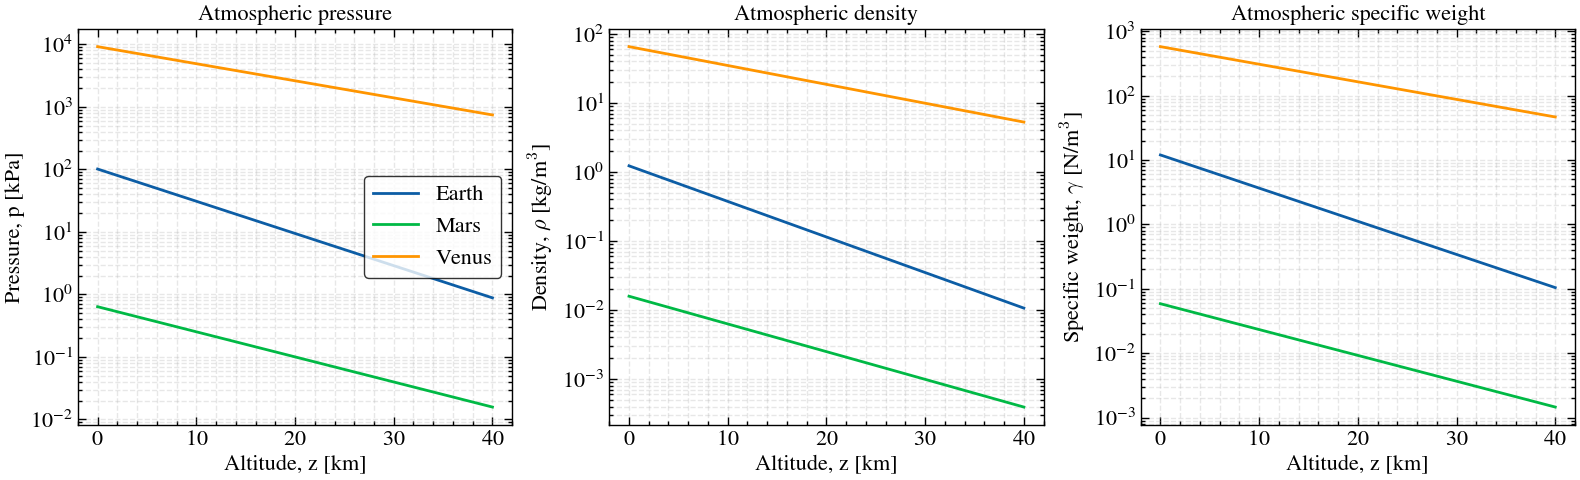

In [14]:
# Altitude range, in m
z = np.linspace(0, 40e3, 500)

# Altitude in km for plotting
z_km = z / 1000

# Create the multi-panel figure
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

for planet in planets:

    # Pressure
    ax[0].plot(
        z_km,
        pressure(z, planet) / 1000,
        label=planet
    )

    # Density
    ax[1].plot(
        z_km,
        density(z, planet),
        label=planet
    )

    # Specific weight
    ax[2].plot(
        z_km,
        specific_weight(z, planet),
        label=planet
    )


# Pressure plot
ax[0].set_xlabel("Altitude, z [km]")
ax[0].set_ylabel("Pressure, p [kPa]")
ax[0].set_title("Atmospheric pressure")
ax[0].set_yscale("log")
ax[0].legend(frameon=True, facecolor="white", edgecolor="black")


# Density plot
ax[1].set_xlabel("Altitude, z [km]")
ax[1].set_ylabel(r"Density, $\rho$ [kg/m$^3$]")
ax[1].set_title("Atmospheric density")
ax[1].set_yscale("log")


# Specific weight plot
ax[2].set_xlabel("Altitude, z [km]")
ax[2].set_ylabel(r"Specific weight, $\gamma$ [N/m$^3$]")
ax[2].set_title("Atmospheric specific weight")
ax[2].set_yscale("log")


# Format all panels
for axis in ax:
    axis.grid(True, which="both", linestyle="--", alpha=0.3)


plt.tight_layout()
plt.show()

On a logarithmic Y, linear-$z$ plot each curve is a straight line, since $\ln p = \ln p_0 - z/H$. The logarithmic scale allows the large differences between the planetary atmospheres to be compared clearly.

The slope of each line is $-1/H$, so the scale height can be obtained as $H=-1/\text{slope}$. Therefore, Venus with the largest $H$ corresponds to a slow decay and the atmospheric properties decrease more slowly with altitude, while for Earth with the smallest $H$, we have a steeper decay.

## Buoyancy on the probe:

#### **(c)** Calculate the **buoyant force** on the probe for each planet in 2 independent ways: first with Archimedes' principle, $F_B = \gamma(z_c)\,\mathcal{V}$, and then by evaluating the surface integral for $F_z$ given above **numerically**. Report both values and the relative error between them, and explain why $F_z$ must come out **upward**. Then, split the sphere at $z = z_c$ and report the vertical pressure force on the **lower** and on the **upper** hemisphere separately. Comment on the size of the two numbers compared with their sum.

In [15]:
# Define the probe volume
a = 5.0  # m
z_c = 10.0  # m, probe centre altitude
V = 4 / 3 * np.pi * a**3  # m^3

# Numerical integral
def numerical_pforce(planet, theta_1=0, theta_2=np.pi):
    # Integrand of the vertical pressure force
    def integrand(theta):
        # Altitude of the surface element
        z = z_c + a * np.cos(theta)
        # Vertical component of the pressure force
        return (-2 * np.pi * a**2* pressure(z, planet)* np.cos(theta)* np.sin(theta))

    # Numerical integration
    F_z, _ = integrate.quad(integrand, theta_1, theta_2)

    return F_z

# Store the buoyancy results
buoyancy_results = []

for planet in planets:

    # Archimedes' principle
    F_B = specific_weight(z_c, planet) * V

    # Numerical pressure integral over the whole sphere
    F_z = numerical_pforce(planet)

    # Relative difference between both methods
    relative_error = abs(F_z - F_B) / F_B

    # Store results
    buoyancy_results.append({
        "Planet": planet,
        "Archimedes F_B [N]": F_B,
        "Surface integral F_z [N]": F_z,
        "Relative error": relative_error
    })

# Convert results to a DataFrame
buoyancy_table = pd.DataFrame(buoyancy_results)

buoyancy_table

,Planet,Archimedes F_B [N],Surface integral F_z [N],Relative error
0,Earth,6286.520363,6286.520584,3.518151e-08
1,Mars,30.745984,30.745985,2.135013e-08
2,Venus,302795.335243,302795.338238,9.890057e-09


The vertical component of the outward normal of the sphere $n_z = \cos(\theta)$ is positive for the upper hemisphere and negative for the lower hemisphere ($0 \le \theta \le \pi$). Then, from the force expression, $dF_z = -p n_z dS$, the upper hemisphere produces a downward force and the lower hemisphere an upward force. Also, we need to consider that pressure is slightly higher at the lower hemisphere (pressure increases with depth). Finally, the resultant presure force it's upward as a result.

In [16]:
# Store the hemisphere forces
hemisphere_results = []

for planet in planets:

    # Upper hemisphere: downward force
    F_upper = numerical_pforce(planet, 0, np.pi / 2)

    # Lower hemisphere: upward force
    F_lower = numerical_pforce(planet, np.pi/2, np.pi)

    # Net pressure force
    F_net = F_lower + F_upper

    hemisphere_results.append({
        "Planet": planet,
        "Lower hemisphere [N]": F_lower,
        "Upper hemisphere [N]": F_upper,
        "Net force [N]": F_net
    })

hemisphere_table = pd.DataFrame(hemisphere_results).set_index("Planet")

hemisphere_table

,Lower hemisphere [N],Upper hemisphere [N],Net force [N]
Planet,,,
Earth,7.952148e+06,-7.945862e+06,6286.520584
Mars,4.992056e+04,-4.988981e+04,30.745985
Venus,7.222634e+08,-7.219606e+08,302795.338238


Each individual pressure force is in the order of millions of newtons while their sum is of order thousands of newtons. But the net force, the buoyant force, is positive as stated above, which is the difference between the two large pressure forces acting on each hemisphere.

#### **(d)** Now evaluate the same integral **analytically with SymPy**. Show that the result can be written as:

$$F_z = \gamma(z_c)\,\mathcal{V}\;\Phi(\epsilon), \qquad \epsilon = \frac{a}{H}$$

and report the function $\Phi(\epsilon)$. Expand $\Phi$ for $\epsilon \ll 1$ and report its first two terms. Does Archimedes' principle evaluated with the local $\gamma(z_c)$ overestimate or underestimate the exact pressure integral? Make a labeled plot of $\Phi$ versus $\epsilon$, find the value of $\epsilon$ at which $\Phi$ departs from $1$ by $1\%$, and convert it into a probe radius in $\rm km$ for each planet.

In [17]:
# Define symbolic variables
theta, a_sym, p_c, epsilon = sp.symbols("theta a p_c epsilon", positive=True)

# Pressure variation over the sphere
p_surface = p_c * sp.exp(-epsilon * sp.cos(theta))

# Vertical pressure-force integral
F_z_sym = -2 * sp.pi * a_sym**2 * sp.integrate(
    p_surface * sp.cos(theta) * sp.sin(theta),
    (theta, 0, sp.pi))

# Simplify the result
F_z_sym = sp.simplify(F_z_sym)

# Local Archimedes force
F_arch_sym = ( (p_c * epsilon / a_sym) * (4 / 3) * sp.pi * a_sym**3)

# Correction factor Phi(epsilon)
Phi = sp.simplify(F_z_sym / F_arch_sym)

print("Phi(epsilon) [from SymPy]:")
Phi

Phi(epsilon) [from SymPy]:


1.5*(epsilon + (epsilon - 1)*exp(2*epsilon) + 1)*exp(-epsilon)/epsilon**3

In [18]:
# Series expansion for small epsilon
Phi_series = sp.series(Phi, epsilon, 0, 6)

Phi_series

1.0 + 0.1*epsilon**2 - 5.55111512312578e-17*epsilon**3 + 0.00357142857142861*epsilon**4 + O(epsilon**6)

Thus, $\Phi(\epsilon) > 1$ for any nonzero radius, up to the two first terms. So,
$$
\gamma(z_c)\,\mathcal{V}\;\Phi(\epsilon) > \gamma(z_c)\,\mathcal{V},
$$
$$
F_z > F_B.
$$
Thus, Archimedes' principle slightly understimates the exact force.

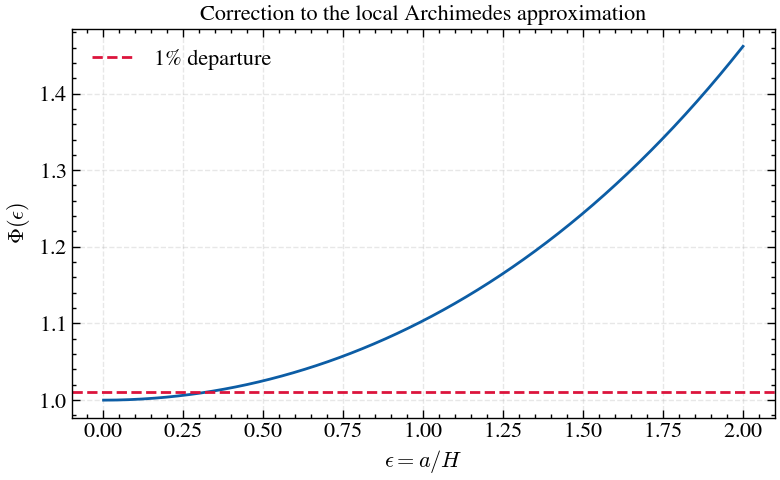

epsilon for 1% deviation = 0.315666


,Planet,H [km],a for 1% error [km]
0,Earth,8.429681,2.660960
1,Mars,10.820965,3.415806
2,Venus,15.898791,5.018701


In [19]:
# Numerical function for Phi
def phi(epsilon):
    return (
        3
        * (epsilon * np.cosh(epsilon) - np.sinh(epsilon))
        / epsilon**3
    )


# Range of epsilon values
epsilon_values = np.linspace(1e-3, 2.0, 500)

# Calculate Phi
phi_values = phi(epsilon_values)


# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    epsilon_values,
    phi_values,
    linewidth=2
)

# Archimedes approximation
plt.axhline(
    1.01,
    color="crimson",
    linestyle="--",
    label="1% departure"
)

plt.xlabel(r"$\epsilon=a/H$")
plt.ylabel(r"$\Phi(\epsilon)$")
plt.title("Correction to the local Archimedes approximation")

plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


# Find epsilon for a 1% departure from Phi = 1, root-finding
epsilon_1pct = brentq(lambda eps: phi(eps) - 1.01, 0.01,1.0)

print(f"epsilon for 1% deviation = {epsilon_1pct:.6f}")

# Store the probe radius corresponding to 1% error
radius_results = []

for planet in planets:

    # Get scale height
    _, _, _, H = atmosphere_properties(planet)

    # Radius for a 1% departure
    a_1pct = epsilon_1pct * H

    # Store results
    radius_results.append({
        "Planet": planet,
        "H [km]": H / 1000,
        "a for 1% error [km]": a_1pct / 1000
    })


# Convert to DataFrame
radius_table = pd.DataFrame(radius_results)

radius_table

So the probe must have a radius of kilometres, not metres, before the local Archimedes approximation is wrong by even $1 \%$.

## Equilibrium and stability:

#### **(e)** For each planet, calculate the total probe mass $m$ that would make it **neutrally buoyant** at $z = z_c$. Then fix $m = 600\,\rm kg$ and make a high-quality, labeled plot of $F_B(z) = \gamma(z)\,\mathcal{V}$ and of the weight $m\,g$ as a function of altitude. Using the local-$\gamma$ Archimedes model, find the equilibrium altitude $z_{\rm eq}$, where $\gamma(z_{\rm eq})\,\mathcal{V} = m\,g$, by numerical root finding, and check it against the analytical solution:

$$z_{\rm eq} = H\,\ln\left(\frac{\rho_0\,\mathcal{V}}{m}\right)$$

State, for each planet, whether the probe rises, descends to the ground, or settles at an equilibrium altitude above the ground.

To get the neutral mass, we equate the weight and the buoyant force,
$$
\gamma(z_c)\,\mathcal{V} = mg,
$$
$$
\rho(z_c)\,g\,\mathcal{V} = mg,
$$
$$
m = \rho(z_c)\,\mathcal{V}.
$$

In [20]:
# Probe mass for neutral buoyancy at z_c
neutral_results = []

for planet in planets:

    # Atmospheric density at the probe centre
    rho_c = density(z_c, planet)

    # Neutral probe mass
    m_neutral = rho_c * V

    # Store results
    neutral_results.append({
        "Planet": planet,
        "Neutral mass [kg]": m_neutral
    })

# Convert results to DataFrame
neutral_table = pd.DataFrame(neutral_results)

neutral_table

,Planet,Neutral mass [kg]
0,Earth,640.827764
1,Mars,8.287327
2,Venus,34137.016375


Using Archimedes' model, the net vertical force is,
$$
F_{net}(z) = \gamma(z)\,\mathcal{V} - mg.
$$

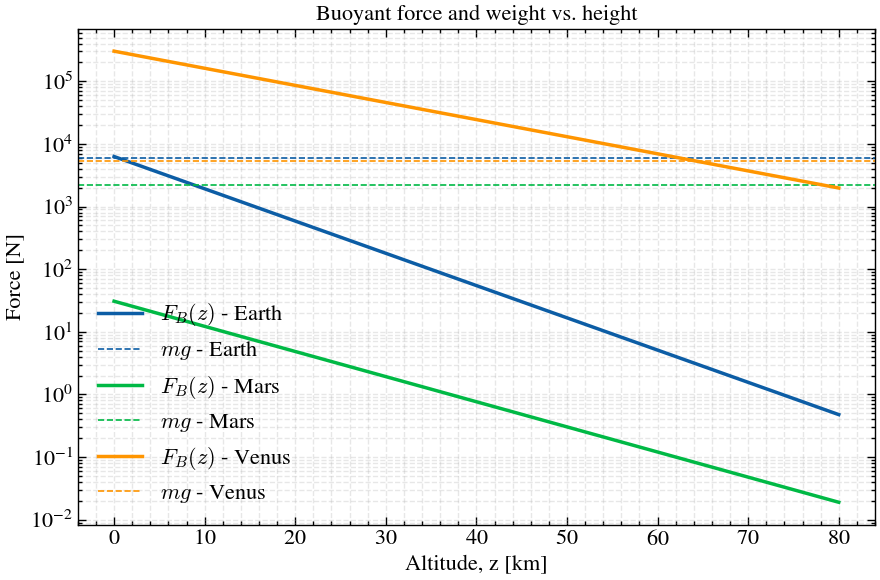

In [21]:
# Probe mass
m = 600.0  # kg


# Calculate the net vertical force
def net_force(z, planet, m):

    # Buoyant force
    F_B = specific_weight(z, planet) * V

    # Probe weight
    W = m * planets[planet]["g"]

    return F_B - W

# Altitude range
z_plot = np.linspace(0, 80e3, 800)
z_plot_km = z_plot / 1000

# Create a single figure
plt.figure(figsize=(9, 6))

for planet in planets:

    # Buoyant force as a function of altitude
    F_B = specific_weight(z_plot, planet) * V

    # Probe weight
    W = m * planets[planet]["g"]

    # Plot buoyant force and obtain its color
    line, = plt.plot(
        z_plot_km,
        F_B,
        linewidth=2.5,
        label=fr"$F_B(z)$ - {planet}"
    )

    # Use the same color for the corresponding weight
    plt.axhline(
        W,
        color=line.get_color(),
        linestyle="--",
        linewidth=1.2,
        label=fr"$mg$ - {planet}"
    )

plt.xlabel("Altitude, z [km]")
plt.ylabel("Force [N]")
plt.title("Buoyant force and weight vs. height")

plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Finding the equilibrium altitude
# Maximum altitude for the root search
z_max = 100e3  # m

# Store equilibrium results
equilibrium_results = []

for planet in planets:

    # Get atmospheric properties
    _, rho0, _, H = atmosphere_properties(planet)

    # Analytical equilibrium altitude
    z_eq_analytical = H * np.log(rho0 * V / m)

    # Net force at the limits of the physical domain
    F_ground = net_force(0, planet, m)
    F_top = net_force(z_max, planet, m)

    # Check if the net force changes sign
    if F_ground * F_top < 0:

        # Numerical equilibrium altitude
        z_eq_numerical = brentq(lambda z: net_force(z, planet, m), 0, z_max)

    else:

        # No equilibrium above the ground
        z_eq_numerical = np.nan

    # Store results
    equilibrium_results.append({
        "Planet": planet,
        "Numerical z_eq [km]": z_eq_numerical / 1000
            if not np.isnan(z_eq_numerical) else np.nan,
        "Analytical z_eq [km]": z_eq_analytical / 1000
    })

# Convert results to a DataFrame
equilibrium_table = pd.DataFrame(equilibrium_results)

equilibrium_table

,Planet,Numerical z_eq [km],Analytical z_eq [km]
0,Earth,0.564935,0.564935
1,Mars,NaN,-46.327560
2,Venus,64.260322,64.260322


For $m=600 \,\mathrm{kg}$, the probe rises from $z_c = 0.01 \,\mathrm{km}$ until it reaches equilibrium at approximately $0.56 \,\mathrm{km}$ on Earth and $64 \,\mathrm{km}$ on Venus. On Mars, the atmosphere is too thin to provide sufficient buoyancy, so the probe descends to the ground.

#### **(f)** Show that this equilibrium is **vertically stable** by calculating the net force $F_{\rm net}(z) = \gamma(z)\,\mathcal{V} - m\,g$ in the vicinity of $z_{\rm eq}$ and its slope there. Using $F_{\rm net}\simeq -k\,(z-z_{\rm eq})$ with $k = -dF_{\rm net}/dz$ evaluated at $z_{\rm eq}$, obtain the period of the small vertical oscillations of the probe about its equilibrium altitude **in this linearised model**, and evaluate it for each planet. (**Hint:** your final expression for the period should depend only on $H$ and $g$).

The net vertical force on the probe is

$$
F_{\rm net}(z)=\gamma(z)\mathcal V-mg.
$$

For our atmosphere model,

$$
\gamma(z)=\gamma_0 e^{-z/H}.
$$

So,

$$
F_{\rm net}(z)=\gamma_0 \mathcal V e^{-z/H}-mg.
$$

To determine the stability at equilibrium ($\gamma(z_{\rm eq})\mathcal V=mg,$), we differentiate the net force with respect to altitude:

$$
\frac{dF_{\rm net}}{dz}
=
-\frac{\gamma_0 \mathcal V}{H}e^{-z/H},
$$

$$
\frac{dF_{\rm net}}{dz}
=
-\frac{\gamma(z)\mathcal V}{H},
$$

$$
\left.
\frac{dF_{\rm net}}{dz}
\right|_{z_{\rm eq}}
=
-\frac{mg}{H}.
$$

Because

$$
\left.
\frac{dF_{\rm net}}{dz}
\right|_{z_{\rm eq}}<0,
$$

the equilibrium is stable: a displacement above the equilibrium produces a downward force, while a displacement below it produces an upward force.

For small displacements around equilibrium,

$$
F_{\rm net}\simeq-k(z-z_{\rm eq}),
$$

where

$$
k=
-\left.
\frac{dF_{\rm net}}{dz}
\right|_{z_{\rm eq}}.
$$

Therefore,

$$
k=\frac{mg}{H}.
$$

If we define the small displacement

$$
\xi=z-z_{\rm eq},
$$

Newton's second law gives

$$
m\ddot{\xi}=-k\xi.
$$

Hence,

$$
\ddot{\xi}+\frac{k}{m}\xi=0,
$$

which is the equation of simple harmonic motion. Therefore,

$$
\omega^2=\frac{k}{m}.
$$

Substituting

$$
k=\frac{mg}{H},
$$

we obtain

$$
\omega^2=\frac{g}{H},
$$

and thus

$$
\omega=\sqrt{\frac{g}{H}}.
$$

The period of the small vertical oscillations is therefore

$$
T_{\rm osc}
=
\frac{2\pi}{\omega}
=
2\pi\sqrt{\frac{H}{g}}.
$$

Thus, in the linearised model, the oscillation period depends only on the atmospheric scale height and the gravitational acceleration.

In [23]:
# Store the oscillation periods
period_results = []

for planet in planets:

    # Get gravity and scale height
    g = planets[planet]["g"]
    _, _, _, H = atmosphere_properties(planet)

    # Small vertical oscillation period
    T_osc = 2 * np.pi * np.sqrt(H / g)

    # Store results
    period_results.append({
        "Planet": planet,
        "H [km]": H / 1000,
        "Period [s]": T_osc,
        "Period [min]": T_osc / 60
    })

# Convert results to a DataFrame
period_table = pd.DataFrame(period_results)

period_table

,Planet,H [km],Period [s],Period [min]
0,Earth,8.429681,184.183591,3.069727
1,Mars,10.820965,339.332856,5.655548
2,Venus,15.898791,266.011316,4.433522


The oscillation period depends only on the atmospheric scale height and gravity. For the $600 \,\mathrm{kg}$ probe in Mars, this is only a formal result because it has no equilibrium altitude above the ground.

#### **(g)** Finally, the **rotational equilibrium**. The probe carries ballast, so that its centre of gravity sits a distance $\Delta z_G$ below the geometric centre of the sphere, at $z_G = z_c - \Delta z_G$. Because $p = p(z)$ and the sphere is symmetric about its centre, all horizontal pressure-force components cancel and the resultant buoyant force acts along the vertical through the geometric centre, in any orientation of the probe. Taking moments about the centre of gravity, about which the weight itself produces no moment, show that a probe tilted by an angle $\varphi$ away from the vertical experiences

$$\tau = F_B\,(z_c - z_G)\,\sin\varphi$$

where $\tau$ is counted positive when it acts to restore the probe to $\varphi = 0$. Using the Archimedes value $F_B = \gamma(z_c)\,\mathcal{V}$ of point (c), evaluate $\tau$ for each planet with $\Delta z_G = 0.5\,\rm m$ and $\varphi = 5^{\circ}$, and say in each case whether the upright orientation is stable or unstable.

The buoyant force acts vertically through the geometric centre of the spherical probe, while the weight acts through the centre of gravity. Since the ballast places the centre of gravity below the geometric centre,

$$
\Delta z_G=z_c-z_G.
$$

If the probe is tilted by an angle $\varphi$, the perpendicular lever arm of the buoyant force about the centre of gravity is

$$
\Delta z_G\sin\varphi.
$$

Therefore, the restoring torque is

$$
\tau
=
F_B\Delta z_G\sin\varphi.
$$

Using Archimedes,

$$
F_B=\gamma(z_c)\mathcal V,
$$

the torque becomes

$$
\tau
=
\gamma(z_c)\mathcal V\Delta z_G\sin\varphi.
$$

Since the centre of gravity lies below the geometric centre, the torque acts to reduce the tilt angle and return the probe to the vertical position. 

The buoyant force creates a torque that tends to return the probe to $\varphi=0$. Therefore, the upright orientation is rotationally stable.

For small angles,

$$
\sin\varphi \approx \varphi,
$$

so the restoring torque is approximately proportional to the tilt angle.

In [24]:
# Rotational displacement
delta_z_G = 0.5              # m
varphi = np.deg2rad(5)       # rad

# Reuse the Archimedes buoyant force from part (c)
torque_table = buoyancy_table[
    ["Planet", "Archimedes F_B [N]"]
].copy()

# Calculate the restoring torque
torque_table["Torque [N·m]"] = (
    torque_table["Archimedes F_B [N]"]
    * delta_z_G
    * np.sin(varphi)
)

# Upright orientation
torque_table["Orientation"] = "Stable"

torque_table

,Planet,Archimedes F_B [N],Torque [N·m],Orientation
0,Earth,6286.520363,273.953176,Stable
1,Mars,30.745984,1.339845,Stable
2,Venus,302795.335243,13195.176172,Stable


## Analysis questions:

#### **(h)** Venus has a surface pressure about $90$ times larger than Earth's, yet the buoyant force you found on it is not as large. Starting from $d\mathbf{F} = -p\,\mathbf{n}\,dS$, show that replacing $p$ by $p + \Delta p$ for an arbitrary constant $\Delta p$ leaves the net force on a closed body unchanged, and explain what that implies about absolute versus gage pressure. What sets the buoyant force? Which atmosphere gives the largest buoyant force for the same displaced volume and why?

Starting from the pressure force on a closed surface,

$$
\mathbf F=-\oint p\,\mathbf n\,dS.
$$

If a constant pressure $\Delta p$ is added everywhere,

$$
\mathbf F'
=
-\oint (p+\Delta p)\mathbf n\,dS
=
\mathbf F-\Delta p\oint\mathbf n\,dS.
$$

For any closed surface,

$$
\oint\mathbf n\,dS=0,
$$

so

$$
\mathbf F'=\mathbf F.
$$

Therefore, a constant pressure offset does not change the net force. This means that using absolute pressure or gauge pressure gives the same resultant force, as long as the same constant reference is applied everywhere on the closed surface. **Buoyancy depends on the pressure gradient**,

$$
\frac{dp}{dz}=-\rho g,
$$

so

$$
F_B=\rho g\mathcal V=\gamma\mathcal V.
$$

Hence, buoyancy is controlled by atmospheric density and gravity, not by absolute pressure alone. For the same displaced volume, Venus gives the largest buoyant force because it has the largest local specific weight $\gamma=\rho g$. Earth is next, while Mars gives the smallest buoyancy because of its very low atmospheric density.

#### **(i)** From your result in point (d), how large would the probe have to be before Archimedes' principle evaluated with the local $\gamma(z_c)$ is wrong by $1\%$? What does this justify about treating $\gamma$ as constant over the probe, and in what kind of problem would that assumption fail? Then look again at the two hemispheric forces of point (c): why is $F = p\,A$ not a valid way to obtain them, and what does the size of the absolute pressure load imply for the structural design of a Venus probe?

The local Archimedes expression assumes that $\gamma$ is essentially constant over the sphere, whereas the exact integral accounts for its variation with altitude. From part (d), a $1\%$ error occurs at approximately
$$
\epsilon=\frac{a}{H}\approx0.316.
$$
So the probe must have a radius of kilometres, not metres, before the local Archimedes approximation is wrong by even $1 \%$.

Since the actual probe radius is only $5\,\mathrm{m}$, $a/H\ll1$, so treating $\gamma$ as constant over the probe is an excellent approximation. This assumption would fail for bodies whose size is no longer small compared with the atmospheric scale height.

For each hemisphere, $F=pA$ is not valid because pressure is not uniform over the curved surface and the pressure force acts normal to each surface element. Therefore, the vertical force must be obtained from

$$
F_z=-\int p\,n_z\,dS.
$$

We found that although the net buoyant force is relatively small, the absolute pressure forces on the probe can be very large.

#### **(j)** The probe has exactly the same geometry and mass on all 3 planets, yet it behaves very differently on each. Explain why. Then explain why, in the usual uniform-density, submerged-body model of the lectures, the rotational result of point (g) would not depend on whether the probe is a sphere or a zeppelin, provided it stays completely submerged, and why that argument needs qualification in a stratified atmosphere such as the one modelled here. What changes for a floating body, for which the lectures introduce the metacentre?

In a nutshell, the different behavior of the probe on each planet is consequence of their different specific weights. 

For a *completely submerged body* in a uniform-density fluid, the buoyant force acts through the centre of buoyancy, which is the centroid of the displaced volume. Therefore, rotational stability depends mainly on the relative positions of the centre of buoyancy and centre of gravity, rather than whether the body is a sphere or a zeppelin.

In a *stratified atmosphere*, however, density varies with altitude. The pressure forces are therefore weighted differently over the body, so for a non-spherical body the magnitude and line of action of buoyancy may depend on its orientation. The simple uniform-density argument then requires qualification.

For a *floating body*, only the submerged volume contributes to buoyancy and its shape changes as the body tilts. This moves the centre of buoyancy, so stability is described using the metacentre: the configuration is stable when the metacentre lies above the centre of gravity.


#### **(k)** Finally, the isothermal atmosphere is a deliberately simplified model: using the temperature profile of the standard atmosphere discussed in the lectures, assess whether each equilibrium altitude of point (e) lies in a region where the isothermal assumption is reasonable. For reference, the Soviet VeGa 1 and VeGa 2 balloons, deployed in the Venusian atmosphere in $1985$, floated at an altitude of about $54\,\rm km$.

For Earth, the equilibrium altitude is only about $0.56 \,\mathrm{km}$. Over such a small height, the atmospheric temperature changes only by a few kelvin, so treating the temperature as approximately constant is a reasonable assumption.

For Mars, the $600,\mathrm{kg}$ probe has no physical equilibrium above the ground, so there is no equilibrium altitude at which to assess the approximation.

For Venus, the predicted equilibrium altitude of about $64,\mathrm{km}$ is far from the surface, where the temperature is much lower than the assumed constant surface value. Therefore, the isothermal assumption is not reasonable over this range and a realistic temperature profile would change the pressure, density and predicted equilibrium altitude. The VeGa balloons floating near $54,\mathrm{km}$ are consistent with buoyant flight occurring in this much cooler region of the Venusian atmosphere.
